# Anomaly Detection using DBSCAN

In [19]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "12"
os.environ["OMP_NUM_THREADS"] = "4"

In [20]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [21]:
X, y = make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42
)

In [22]:
# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

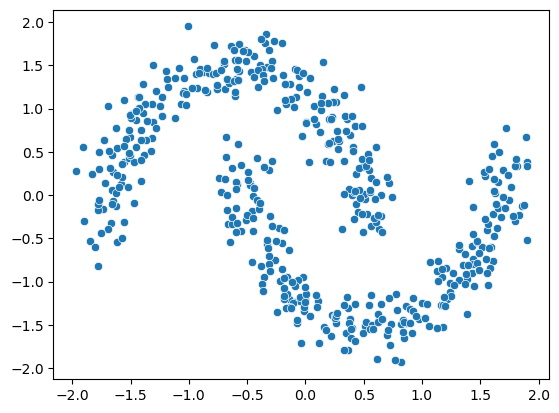

In [23]:
# Visualization

sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1])

In [24]:
# DBSCAN

dbscan = DBSCAN(
    eps=0.18,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

<Axes: >

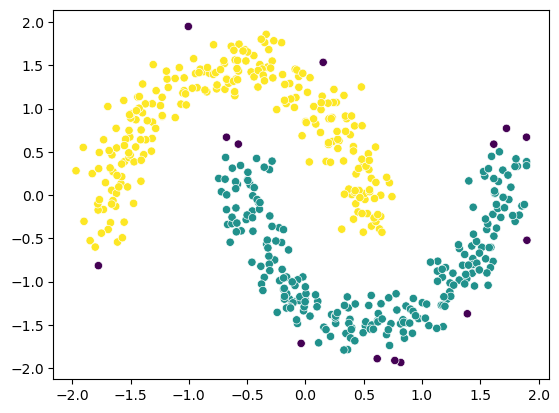

In [25]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], c=labels)

# Anomaly Detection using Isolation Forest

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("thyroid_dataset.csv", sep=";")
df = df.dropna(axis=1)

In [27]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,49.0,3.0,5.0,116.0,4.0,o


In [28]:
X = df.drop("Outlier_label ", axis=1)
y = df["Outlier_label "]

In [29]:
# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# Isolation Forest

from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=200, contamination='auto', random_state=42)

In [31]:
labels = clf.fit_predict(X_scaled)

In [32]:
# Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

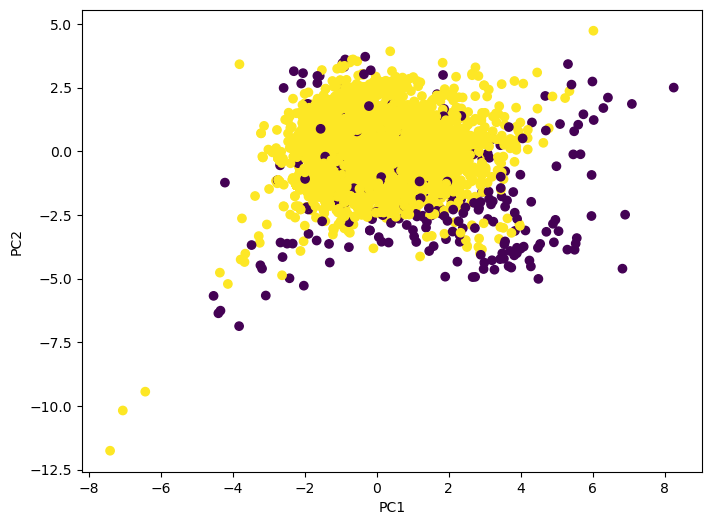

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [34]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outlier =", n_outliers)
print("normal =", n_normal)

outlier = 270
normal = 6646


# Anomaly Detection using LOF

In [35]:
from sklearn.neighbors import LocalOutlierFactor

In [36]:
neighbs = LocalOutlierFactor()

labels = neighbs.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

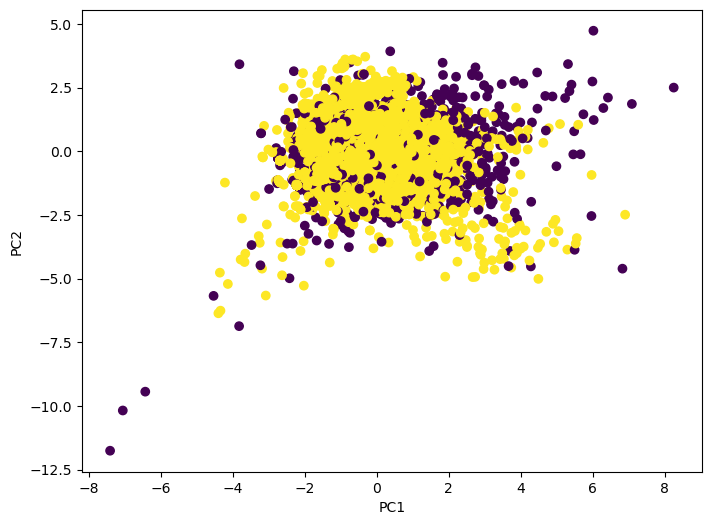

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [39]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outlier =", n_outliers)
print("normal =", n_normal)

outlier = 883
normal = 6033
